## Libraries

In [2]:
using KadanoffBaym, LinearAlgebra, BlockArrays
using Bessels
using PyPlot
using Tullio
⊗(A,B) = kron(A,B)

⊗ (generic function with 1 method)

## Parameters and predifined quantities

In [3]:
hbar = 1.#0.658211928e0  
### Pauli matrices
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1])
σ_x =  Matrix{ComplexF64}([0 1; 1 0])
σ_y =  Matrix{ComplexF64}([0 -1im ; 1im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1]) ; 

In [4]:
# Lattice size
L = 2
nσ = 2
nx = L
ny = 1
γ = 1
γso = 0
j_sd = 0
# Allocate the initial Green functions (time arguments at the end)
GL = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian)
GG = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian);
Ht = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian);
# GL_d = GreenFunction(zeros(ComplexF64, L, L, 1, 1), SkewHermitian)
# GG_d = GreenFunction(zeros(ComplexF64, L, L, 1, 1), SkewHermitian);

In [5]:
I_a1b1 = Matrix{ComplexF64}(I, L, L)           # Identity on lattice space
I_ab = Matrix{ComplexF64}(I, nσ*L, nσ*L)        # Identity on lattice ⊗ spin
# --- Pauli matrices extended to the full Hilbert space ---
σ_x1ab = kron(I_a1b1, σ_x)
σ_x2ab = kron(I_a1b1, σ_y)
σ_x3ab = kron(I_a1b1, σ_z)
# --- Pauli matrices as a 3D array σ_abx[μ, i, j] ---
σ_ijx = cat(σ_x1ab, σ_x2ab, σ_x3ab; dims=3) ;

### Auxiliary integrator

In [6]:
function integrate0(t1,t2,A)
    retval = 0.0
    dt = 0.01
    ts = t2:dt:t1
    A_vec = A.(ts)
    @tullio retval = A_vec[α]
    retval = retval*dt
end
# Auxiliary integrator for the first type of integral
function integrate1(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t1)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k] - B[t1, k], C[k, t2], hs[k], 1.0)
    end
    return retval
end
# Auxiliary integrator for the second type of integral
function integrate2(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t2)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k], B[k, t2] - C[k, t2], hs[k], 1.0)
    end
    return retval
end

integrate2 (generic function with 1 method)

### Precesion 

In [7]:
mutable struct PrecSpin
    """ This mutable structure act like a class 
    in python, it defines an object with the 
    characteristics of a precessing spin
    """
    i::Int64 #   
    axis_phi::Float64 
    axis_theta::Float64 
    phi_zero::Float64 
    theta_zero::Float64 
    start_time::Float64 
    T::Float64 
    s::Vector{Float64} 
    ### Initial values of PrecSpin .
    function PrecSpin(i=0,axis_phi=0.0,axis_theta=0.0,
            phi_zero=0.0,theta_zero=0.0,start_time=0.0
            ,T=1.,s=[0.,0.,1.])
        new(i,axis_phi,axis_theta,phi_zero,theta_zero,start_time,T,s)
    end
end

function update!(this::PrecSpin, time  )
    """ This function  update the magnetic moment associated
    to the mutable structure PrecSpin 
    
    parameters:
    ----------
    this: mutable structure 
    contain an structure with the characteristics of a spin 
    time: Float64
    time where the spin is evaluated 
    
    returns:
    -------
    Update the strucure associated to a  precessing spin 
    """
    if time >= this.start_time
        t = time - this.start_time
    else
        t = 0.0
    end
    omega = 2*pi / this.T
    otheta = pi*this.theta_zero/180.
    ophi = pi*this.phi_zero /180. ##########
    # compute spin position for precession along the z-axis
    sz = cos(otheta)
    sx = cos(ophi + omega*t)*sin(otheta)
    sy = sin(ophi + omega*t)*sin(otheta)
    # Now rotate along y 
    atheta = pi * this.axis_theta/ 180.
    aphi = pi * this.axis_phi / 180. 
    sx = sx*cos(atheta) - sz* sin(atheta)
    sz = sx* sin(atheta) + sz*cos(atheta)
    # No rotate along the z 
    sx = sx*cos(aphi) + sy*sin(aphi)
    sy = -sx*sin(aphi) + sy*cos(aphi)
    this.s .= [sx, sy, sz]
    nothing
end

update! (generic function with 1 method)

## Self Energy 

In [8]:
#### Dynamical variables 
Base.@kwdef struct FermiHubbardData2B{T}
    GL::T
    GG::T
    ΣL::T # zero(GL)
    ΣG::T # zero(GG)
    Ht::T
end

In [9]:
#### Calculation of the self-energy 
function selfenergy(ϵ;γ=1,γc=1.)# thop = thop, t_ls = 1.) 
    ### Note that this configuration for the self energy can be modified later
    #thop = global_var.thop
    Δ = 4 * γ^2 - ϵ^2
    if real(Δ) > 0
        Σ = ϵ - im * sqrt(Δ)
    else
        if real(ϵ) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ = ϵ - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end
function Gamma_ϵ(ϵ;γ=1,γc=1.)#
    -2*imag(selfenergy(ϵ;γ=γ,γc=γc))
end
#using Bessels
function Gamma_t(t;γ=1,γc=1.)#
    γ^2/(γc^2)*γ^2*(besselj(0, 2*γ*t)+ besselj(2, 2*γ*t))#*exp(1im*μ*t)
    #-2*imag(selfenergy(ϵ;γ=γ,γc=γc))
end
function Gamma2_t(t;γ=1,γc=1.)#
    retval = 0.0
    dϵ = 0.01
    ϵs = -2γ:dϵ:2γ
    Gamma = Gamma_ϵ.(ϵs;γ,γc)
    e = exp.(-1im*ϵs*t)
    @tullio retval = Gamma[α]*e[α]
    retval = retval*dϵ/2pi#/(length(ϵs))
end
function fermi_mu(ϵ; μ=0.0, Temp=300)
    KB = 8.6173324e-5           ### Bolzmann factor
   1/(1. + exp((ϵ-μ)/(KB*Temp)  ))   
end
function SelfL(t;γ=1,γc=1.)
    retval = 0.0
    dϵ = 0.01
    ϵs = -2γ:dϵ:2γ
    Gamma = Gamma_ϵ.(ϵs;γ,γc)
    e = exp.(-1im*ϵs*t)
    f = fermi_mu.(ϵs)
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = 1im*retval*dϵ/2pi
end
function SelfG(t;γ=1,γc=1.)
    retval = 0.0
    dϵ = 0.01
    ϵs = -2γ:dϵ:2γ
    Gamma = Gamma_ϵ.(ϵs;γ,γc)
    e = exp.(-1im*ϵs*t)
    f = -fermi_mu.(ϵs) .+ 1
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = -1im*retval*dϵ/2pi
end

SelfG (generic function with 1 method)

In [33]:
8.6173324e-5*300 

0.025851997199999997

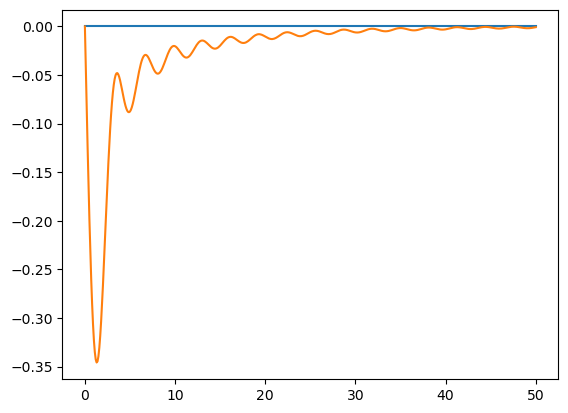

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fc0118b5910>

In [30]:
# ts = 0.0:0.1:50


# Selfk(t) = (SelfL(t;γ=1,γc=1.) + SelfG(t;γ=1,γc=1.))*0.5
# Selfa(t) = (SelfG(t;γ=1,γc=1.) - SelfL(t;γ=1,γc=1.))
# # plt.plot(ts,imag(SelfL.(ts;γ=1,γc=1.)),label="im")
# # plt.plot(ts,real(SelfL.(ts;γ=1,γc=1.)),label="real")
# plt.plot(ts,imag(Selfk.(ts)),label="im")
# plt.plot(ts,real(Selfk.(ts)),label="real")
# plt.legend()

In [34]:
# plt.plot(ts,imag(Selfa.(ts)),label="im")
# plt.plot(ts,real(Selfa.(ts)),label="real")

In [10]:
# Callback function for the self-energies #### This function includes the modifcation in time of the general equations of motion 

function self_Lead!(model,data,times,_,_,t,t′)
    # Unpack data and model 
    (;GL,GG,ΣL,ΣG,Ht) = data
    (;hss, Δ1, Δ2) = model
    ∫ds(A) = integrate0(times[t],times[t′], A  ) 
    # Resize self energies 
    if (n = size(GL,3)) > size(ΣL,3)
        resize!(ΣL, n)
        resize!(ΣG, n)
        resize!(Ht, n)
    end
    ### Time dependece of the leads 
    ϕ1_t = ∫ds(Δ1)#Δ1(times[t], times[t′] )
    ϕ2_t = ∫ds(Δ2)
    #Δ2_t = Δ2(times[t], times[t′] )
    ### Setting the component of the left self-energy
    self = SelfL(times[t] - times[t′];γ=1.0,γc=1.0)
    selfL0 = zeros(ComplexF64,L*nσ,L*nσ)
    selfL0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*diagm(ones(nσ))### Left lead selfenergy 
    selfL0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*diagm(ones(nσ)) ### Right lead selfenergy 
    ### Setting the component of the right self-energy
    self = SelfG(times[t] - times[t′];γ=1.0,γc=1.0)
    selfG0 = zeros(ComplexF64,L*nσ,L*nσ)
    selfG0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*diagm(ones(nσ)) ### Left lead selfenergy 
    selfG0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*diagm(ones(nσ)) ### Right lead selfenergy 
    ### Setting the time dependence of the hamiltonian 
    #########-------------------------------------------------------------------------------############
    Ht[t,t] =  hss(times[t])
    #hs_t(times[t])
    ### Define the self energies 
    ΣL[t, t′] = selfL0#exp()
    ΣG[t, t′] = selfG0
end

self_Lead! (generic function with 1 method)

In [10]:
#SelfL(0.0;γ=1,γc=1.)

function hs_t(t)
    theta_1, phi_1 = 15.0 , 0.0#45.0, 0.0 
    period = 50 
    pr_spins = [PrecSpin(i) for i in 1:1:L  ]        ### array with mutables object of preccesin spins
    for jj in 1: L
        pr_spins[jj].i = jj ## lattice site 
        pr_spins[jj].theta_zero = theta_1
        pr_spins[jj].axis_phi = phi_1
        pr_spins[jj].T = period 
        #println(pr_spins[jj].i)
    end
    vm_i1x = zeros(Float64,nx*ny,3)
    for j in 1:1:nx #3:1:5#n_precessing#length(pr_spins)
        #println(j)
        #dv.vm_i1x[2,:] .= zeros(Float64,3)
        update!(pr_spins[j], t )
        vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
        #println(vm_i1x)
    end   
    #########-------------------------------------------------------------------------------############
    ### Define the Hamiltonian 
    hs(vm_i1x;nx=2,ny=1,γ=1.0,γso=0.0,j_sd=0.1)
end

hs_t (generic function with 1 method)

In [11]:
#hs_t(0)

In [12]:
# Gamma2_t(0.1)
# 1/(2*pi*0.1)
# ϵs = -4:0.1:4
# length(ϵs)
# ts= 0.1:0.1:50
# # plot(ts,Gamma_t.(ts))
# # plot(ts,Gamma2_t.(ts)/2)
# plot(ts,SelfL.(ts))
# plt.ylim(-0.1,0.1)

# # es=-4:0.1:4
# # # plot(es,real(selfenergy.(es)))
# # # plot(es,imag(selfenergy.(es)))
# # plot(es,Gamma_ϵ.(es))
# SelfG(0)

## Hamiltonian 

In [13]:
############# Building Hamiltonian
#### Create electronic Hamiltonian 
function block_h(;ny=1,γ=1,γso=0.0)
    #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
    "Creates the building blocks for a general nx x ny square lattice "
    dim = ny*2 # We include the spin degree of freedom 
    ######
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end

function hs(vm_i1x::Array{Float64,2};nx=nx,ny=1,γ=1,γso=0.0,j_sd=0.1)
    "This function build the central hamiltonian wwith two band"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    dim = nx*ny*2 #*2
    zero = zeros(ComplexF64,nx,nx)
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = block_h(;ny,γ,γso)
    Tx = diagm( -1 =>  ones(nx-1))⊗T 
    HC = (One_x⊗H0) +  Tx + Tx'
    ### Local moments
    for i in range(1,nx) 
        zero[i,i] = 1.0
        HC += -j_sd*zero⊗(vm_i1x[i,1]*σ_x
                    +vm_i1x[i,2]*σ_y
                    +vm_i1x[i,3]*σ_z)
        zero[i,i] = 0.0
    end
    return HC
end


hs (generic function with 1 method)

In [14]:
#### Auxiliary structure with the parameters of the model 
Base.@kwdef struct FermiOpenModel{T1,T2,T3}
    # interaction strength
    # Time dependence of the self energies 
    Δ1::T1
    Δ2::T2
    #U::T
    nx = nx
    ny = ny
    nσ = nσ
    γ = γ
    γso =  γso
    j_sd = j_sd
    # Initial configuration of the classical vectors 
    #vm_i1x = vm_i1x#zeros(Float64,  nx, 3)
    #vm_i1x = zeros(Float64,  L, 3);
    # Hamiltonian of the system 
    hss::T3 
    #hs(vm_i1x;nx,ny,γ,γso,j_sd)
    #H_u = h
    #H_d = h
end

#model.Δ2

## Initial conditions 

In [15]:
### Leviton 
# ts = 0.0:0.1:200
# τ = 6
# t0 = 80
# A = 0.5
# lev(t;t0 = t0,τ = τ) = 2τ/((t-t0)^2+τ^2)
# gauss(t;A=A,t0=t0,τ=τ)=A*exp(-(t-t0)^2/(2*τ^2))
# plt.plot(ts,lev.(ts))
# plt.plot(ts,gauss.(ts))
#model.hs

In [16]:
#Δ1 = t1-> lev(t1;t0 = t0,τ = τ)

In [17]:
# Initial conditions
# τ = 1.0#6
# t0 = 50
# A = 0.5
# Relatively small interaction parameter
U₀ = 0.0
U₁ = 0.0 #0.05
#model = FermiOpenModel(Δ1 = t1-> lev(t1;t0 = t0,τ = τ) ,Δ2 = t2-> U₁)
model = FermiOpenModel(Δ1 = t1-> U₀ ,Δ2 = t2-> U₁,hss = t1->hs_t(t1))
N = zeros(L*nσ)
vm_i1x = zeros(Float64,  L, 3)
# N_d = zeros(L)
# #######
N[1:4] = 0.0 .* [1, 1, 1, 1]
# N_d[1:4] = 0.1 .* [1, 1, 1, 1]
# #######
# N_u[5:8] = 0.0 .* [1, 1, 1, 1]
# N_d[5:8] = 0.0 .* [1, 1, 1, 1]
# #######
GL[1, 1] = 1.0im * diagm(N)
GG[1, 1] = -1.0im * (I - diagm(N)) ;
ΣL = zero(GL)
ΣG = zero(GG)
ΣL[1,1] = SelfL(0;γ=1.0,γc=1.0)*diagm(ones(L*nσ))
ΣG[1,1] = SelfG(0;γ=1.0,γc=1.0)*diagm(ones(L*nσ))
Ht[1,1] = hs(vm_i1x;nx,ny,γ,γso,j_sd)
data = FermiHubbardData2B(GL=GL, GG=GG, ΣL=ΣL, ΣG=ΣG,Ht=Ht) ;
#Ht[2,2]

## EOMS

In [18]:
# Right-hand side for the "vertical" evolution
function fv!(model, data, out, times, h1, h2, t, t′)
    #### NOTE THAT ANY EXTERNAL TIME DEPENDENCE OG THE FUNCTIONS
    #### SHOULD BE INCLUDED IN AN EXTERNAL CALLBACK FUNCTIONS 
    # Unpack data and model
    (; GL, GG, ΣL, ΣG, Ht) = data
    (; hss, Δ1, Δ2) = model ### How to modify the Hamiltonian to include the time dependence 
    # Real-time collision integrals
    ∫dt1(A, B, C) = integrate1(h1, t, t′, A, B, C)
    ∫dt2(A, B, C) = integrate2(h2, t, t′, A, B, C)
    # Equations of motion
    out[1] = -1.0im * ( Ht[t,t]* GL[t, t′] +
        ∫dt1(ΣG, ΣL, GL) + ∫dt2(ΣL, GL, GG)) #### For G<
    out[2] = -1.0im * (Ht[t,t]* GG[t, t′] +
        ∫dt1(ΣG, ΣL, GG) + ∫dt2(ΣG, GL, GG)) #### For G>
    return out
end
# Right-hand side for the "diagonal" evolution
function fd!(model, data, out, times, h1, h2, t, t′)
    fv!(model, data, out, times, h1, h2, t, t)
    out[1] .-= adjoint.(out[1])
    out[2] .-= adjoint.(out[2])
end
# Right-hand side for the "diagonal" evolution
function fd!(model, data, out, times, h1, h2, t, t′)
    fv!(model, data, out, times, h1, h2, t, t)
    out .-= adjoint.(out)
end

fd! (generic function with 1 method)

## Evolution

In [19]:
# final time
tmax = 200#120#120#20#100#80

# tolerances
atol = 1e-6#1e-8#1e-7#
rtol = 1e-5#1e-6#1e-4#

# Call the solver
elapsed_time = @elapsed begin
sol = kbsolve!(
    (x...) -> fv!(model, data, x...),
    (x...) -> fd!(model, data, x...),
    [data.GL, data.GG],
    (0.0, tmax);
    callback = (x...) -> self_Lead!(model, data, x...),
    atol = atol,
    rtol = rtol,
    stop = x -> (println("time : $(x[end])"); flush(stdout); false)
)
end
println("Total time of simulation: ", elapsed_time, " s" )

time : 0.0
time : 1.0e-6
time : 2.063834556811931e-6
time : 3.271074247714341e-6
time : 4.570182560327162e-6
time : 1.1065724123391268e-5
time : 4.3543431938711794e-5
time : 0.0002059319710153144
time : 0.00035208165618425674
time : 0.0010828300820289686
time : 0.004736572211252527
time : 0.00802494012755373
time : 0.02446677970905974
time : 0.03926443533241515
time : 0.1132527134491922
time : 0.17984216375429155
time : 0.3168559024126115
time : 0.3168559024126115
time : 0.46340072871709076
time : 0.595291072391122
time : 0.7392345417838511
time : 0.8687836642373072
time : 1.0147069298151732
time : 1.1460378688352526
time : 1.2903832038117458
time : 1.4451465834656518
time : 1.6048227260104317
time : 1.763523574767612
time : 1.9233246160401578
time : 2.0779036907181996
time : 2.236223972724466
time : 2.378712226530106
time : 2.5202989127526423
time : 2.666256825443522
time : 2.81506021821003
time : 2.9631202849281695
time : 3.1151480132207414
time : 3.2644872748946168
time : 3.41708658

### Calculation of observables 

### Charge current 

In [101]:
### Calculation of the current 
# Auxiliary integrator for the first type of integral
function PI1(hs::Vector, t1, A::GreenFunction, B::GreenFunction)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:t1
        @views LinearAlgebra.mul!(retval, A[t1, k] , B[k, t1], hs[k], 1.0)
    end
    return retval
end
∫dss(t,A, B) = PI1(sol.w[t], t, A, B)

∫dss (generic function with 1 method)

In [102]:
tss = 1:1:length(sol.t)

1:1:1013

In [103]:
size_t = length(tss) 
Σ0L_left = zeros(ComplexF64,4,4,size_t,size_t) #zero(ΣL) 
Σ0L_right = zeros(ComplexF64,4,4,size_t,size_t) 
Σ0L_left[1:2,1:2,:,:]=ΣL[1:2,1:2,:,:] 
Σ0L_right[3:4,3:4,:,:]=ΣL[3:4,3:4,:,:] 
ΣL_left = GreenFunction(Σ0L_left, SkewHermitian)
ΣL_right = GreenFunction(Σ0L_right, SkewHermitian)

Σ0G_left = zeros(ComplexF64,4,4,size_t,size_t) #zero(ΣL) 
Σ0G_right = zeros(ComplexF64,4,4,size_t,size_t) 
Σ0G_left[1:2,1:2,:,:]=ΣG[1:2,1:2,:,:] 
Σ0G_right[3:4,3:4,:,:]=ΣG[3:4,3:4,:,:] 
ΣG_left = GreenFunction(Σ0G_left, SkewHermitian)
ΣG_right = GreenFunction(Σ0G_right, SkewHermitian);

In [104]:
#Π(t) = ∫dss(t,GG, ΣL)- ∫dss(t,GL, ΣG)
Π_left(t) = ∫dss(t,GG, ΣL_left)- ∫dss(t,GL, ΣG_left)
Π_right(t) = ∫dss(t,GG, ΣL_right)- ∫dss(t,GL, ΣG_right)

Π_right (generic function with 1 method)

In [105]:
#Π_left(3)

In [106]:
Curr_left= real(tr.(Π_left.(tss)))
Curr_right= real(tr.(Π_right.(tss)));

In [107]:
cc = [4*pi*Curr_left 4*pi*Curr_right];

### Spin density 

In [78]:
σ_ijx[:,:,2]*imag(GL[10, 10]) 

sy_den[100]

4×4 Matrix{ComplexF64}:
 0.0+0.000462525im  0.0-0.491969im     0.0+1.05923e-8im   0.0-0.301784im
 0.0+0.508031im     0.0-0.000462525im  0.0+0.301784im     0.0+1.05923e-8im
 0.0-1.05923e-8im   0.0-0.301784im     0.0+0.000462492im  0.0-0.491969im
 0.0+0.301784im     0.0-1.05923e-8im   0.0+0.508031im     0.0-0.000462492im

In [83]:
sx_den[100][1,2]

0.49196868967300894 + 0.0im

In [81]:
σ_ijx[:,:,3]

4×4 Matrix{ComplexF64}:
 1.0+0.0im   0.0+0.0im  0.0+0.0im   0.0+0.0im
 0.0+0.0im  -1.0+0.0im  0.0+0.0im  -0.0+0.0im
 0.0+0.0im   0.0+0.0im  1.0+0.0im   0.0+0.0im
 0.0+0.0im  -0.0+0.0im  0.0+0.0im  -1.0+0.0im

In [108]:
sx_den = [-1im*σ_ijx[:,:,1]*GL[t, t] for t in eachindex(sol.t)] ;
sx_1 = [sx_den[t][1,1]+sx_den[t][2,2]  for t in eachindex(sol.t) ]
sx_2 = [sx_den[t][3,3]+sx_den[t][4,4]  for t in eachindex(sol.t) ]

sy_den = [-1im*σ_ijx[:,:,2]*GL[t, t] for t in eachindex(sol.t)] ;
sy_1 = [sy_den[t][1,1]+sy_den[t][2,2]  for t in eachindex(sol.t) ]
sy_2 = [sy_den[t][3,3]+sy_den[t][4,4]  for t in eachindex(sol.t) ]


sz_den = [-1im*σ_ijx[:,:,3]*GL[t, t] for t in eachindex(sol.t)] ;
sz_1 = [sz_den[t][1,1]+sz_den[t][2,2]  for t in eachindex(sol.t) ]
sz_2 = [sz_den[t][3,3]+sz_den[t][4,4]  for t in eachindex(sol.t) ]

sd = real([sx_1 sy_1 sz_1 sx_2 sy_2 sz_2] ) ;
#sx_den[1]

#sy_2

In [95]:
# plt.plot(sx_1)
# plt.plot(sy_1)
# plt.plot(sz_1)

# plt.plot(sx_2)
# plt.plot(sy_2)
# plt.plot(sz_2)

### Charge density

In [109]:
cd1 = [imag(diag(GL[t, t]))[1]  for t in eachindex(sol.t)]
cd2 = [imag(diag(GL[t, t]))[2]  for t in eachindex(sol.t)]
cd3 = [imag(diag(GL[t, t]))[3]  for t in eachindex(sol.t)]
cd4 = [imag(diag(GL[t, t]))[4]  for t in eachindex(sol.t)]

cd = [cd1 cd2 cd3 cd4] ;

In [26]:
#cd;
# PyPlot.plot(sol.t, mapreduce(permutedims, vcat, [imag(diag(GL[t, t])) for t in eachindex(sol.t)]))
# PyPlot.plot(sol.t, [imag(diag(GL[t, t])[1]) for t in eachindex(sol.t)] )
# PyPlot.plot(sol.t, [imag(diag(GL[t, t])[2]) for t in eachindex(sol.t)] )


#cd[:,1]*2

In [27]:
#cd[:,4]*2

### Spin Current 

In [110]:
#eachindex(sol.t)
Π_l_x(t) = σ_ijx[:,:,1]*Π_left(t)
Π_l_y(t) = σ_ijx[:,:,2]*Π_left(t)
Π_l_z(t) = σ_ijx[:,:,3]*Π_left(t)

Π_r_x(t) = σ_ijx[:,:,1]*Π_right(t)
Π_r_y(t) = σ_ijx[:,:,2]*Π_right(t)
Π_r_z(t) = σ_ijx[:,:,3]*Π_right(t)

C_l_x= real(tr.(Π_l_x.(tss)))
C_l_y= real(tr.(Π_l_y.(tss)))
C_l_z= real(tr.(Π_l_z.(tss))) ; 


C_r_x= real(tr.(Π_r_x.(tss)))
C_r_y= real(tr.(Π_r_y.(tss)))
C_r_z= real(tr.(Π_r_z.(tss))) ; 

sc = [4pi*C_l_x 4pi*C_l_y 4pi*C_l_z 4pi*C_r_x 4pi*C_r_y 4pi*C_r_z] ;

## Figures

### Load data 


In [111]:
using PyPlot
using DelimitedFiles
#const plt = PyPlot
# Set rcParams in Julia
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text
fs = 25

25

### Spin density 

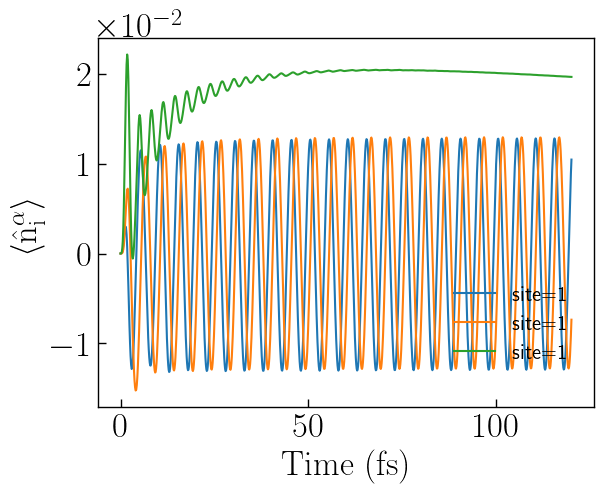

PyObject <matplotlib.legend.Legend object at 0x7f654c83fd70>

In [125]:

fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
# for i in site 
#     axs.plot(ts_cd, cden_ta1[:,i]*det,label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
#     axs.plot(ts_cd, cden_ta1[:,i+1]*det,label= "site=$(i+1)")#
# end
axs.plot(sol.t, sd[:,1],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
axs.plot(sol.t, sd[:,2],label= "site=$(1)")
axs.plot(sol.t, sd[:,3],label= "site=$(1)")
#axs.plot(sol.t, -cd[:,3],label= "site=$(1)",ls = "--")#
#axs.plot(sol.t, cd[:,3].+cd[:,4],label= "site=$(2)")

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(100,120)
#plt.axhline(0.5,ls = "--",color="gray",lw = 0.5)

### Local density 

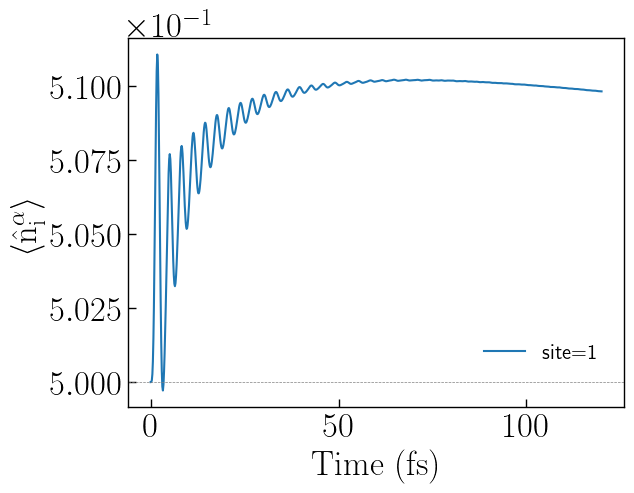

PyObject <matplotlib.lines.Line2D object at 0x7f654ca74740>

In [112]:

fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
# for i in site 
#     axs.plot(ts_cd, cden_ta1[:,i]*det,label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
#     axs.plot(ts_cd, cden_ta1[:,i+1]*det,label= "site=$(i+1)")#
# end
axs.plot(sol.t, cd[:,1],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
#axs.plot(sol.t, -cd[:,3],label= "site=$(1)",ls = "--")#
#axs.plot(sol.t, cd[:,3].+cd[:,4],label= "site=$(2)")

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(100,120)
plt.axhline(0.5,ls = "--",color="gray",lw = 0.5)
#plt.ylim(1-0.1,1+0.1)

In [113]:
cc[:,1]

1013-element Vector{Float64}:
  0.0
  0.0
 -2.6610324844426207e-21
  0.0
  0.0
 -2.1288259875540965e-20
 -3.4061215800865545e-19
  2.554591185064916e-19
 -6.812243160173109e-19
  2.7248972640692436e-18
 -6.267263707359261e-16
  1.6076893858008538e-15
 -1.0408017589838882e-13
  ⋮
 -4.500136222802093e-11
 -6.306883604582937e-10
 -1.083937209661776e-9
 -1.3020764949260142e-9
 -1.2340288999027434e-9
 -8.917884195862036e-10
 -3.4850682845841835e-10
  2.775452392005411e-10
  8.485907213552155e-10
  1.2379320427437962e-9
  1.3578282635348988e-9
  1.3417094389577908e-9

### Charge current 

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


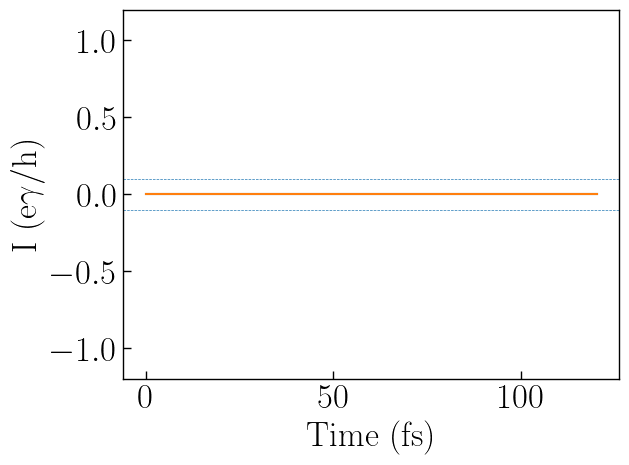

(-1.2, 1.2)

In [114]:
fig,axs = plt.subplots(1,1)

plt.plot(sol.t, cc[:,1])
plt.plot(sol.t, cc[:,2])
axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#plt.xlim(30,80)
plt.axhline(0.1,ls = "--",lw=0.5)
plt.axhline(-0.1,ls = "--",lw=0.5)
#plt.axhline(0.0,ls = "--",lw=0.5)
#plt.axhline(0.05,ls = "--",lw=0.5)
plt.ylim(-2,6.5)
plt.show()
#plt.ylim(-0.05,0.05)
plt.ylim(-1.2,1.2)
#plt.ylim(0.1-1e-2,0.1+1e-2)
#plt.xlim(110,120)

### Spin current

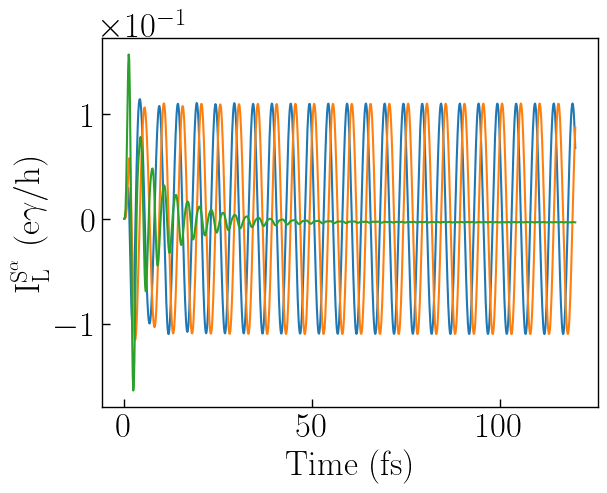

PyObject <matplotlib.legend.Legend object at 0x7f654c572d80>

In [115]:
fig,axs = plt.subplots(1,1)

plt.plot(sol.t, sc[:,1])
plt.plot(sol.t, sc[:,2])
plt.plot(sol.t, sc[:,3])
axs.set_ylabel(L"$\mathrm{I_L^{S^{\alpha}}\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))

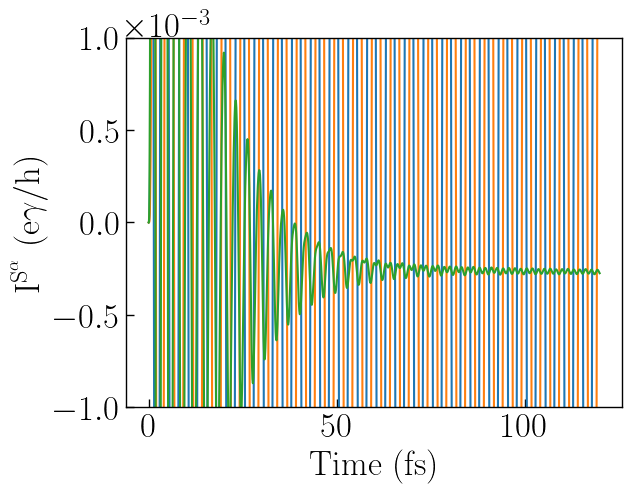

(-0.001, 0.001)

In [116]:
fig,axs = plt.subplots(1,1)

plt.plot(sol.t, C_l_x)
plt.plot(sol.t, C_l_y)
plt.plot(sol.t, C_l_z)
axs.set_ylabel(L"$\mathrm{I^{S^{\alpha}}\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.ylim(-0.001,0.001)

In [117]:


# using DelimitedFiles
# cc_f = open("/home/jalil2/Documents/KBA/data/curr_KBE_jl.txt", "w+") 

# writedlm(cc_f, [sol.t Curr_left], ' ' )

# close(cc_f)

In [118]:
# using DelimitedFiles
# ccL_f = open("./data/ccL_KBE_jl.txt", "w+") 
# ccR_f = open("./data/ccR_KBE_jl.txt", "w+") 
# writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
# writedlm(ccR_f, [sol.t*hbar 4pi*Curr_right], ' ' )
# close(ccL_f)
# close(ccR_f)

In [119]:
#sol.t*hbar
#[sol.t*hbar  4pi*Curr_left]

In [120]:
#4pi*Curr_left[end]/0.05

In [121]:
#4pi*Curr_left[end]

In [122]:
#0.1/0.05
#0.096742516300053/0.05

In [37]:
#plt.plot(sol.t, Curr_right)

In [39]:
#0.05/0.2

## Save data 

In [30]:
using DelimitedFiles
path = "/home/jalil2/Documents/KBA/data"
name = "KBE_3";

### Spin density 

In [100]:
sd_f = open("$(path)/sd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sd_f, [sol.t sd], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sd_f)

### Spin current

In [31]:
sc_f = open("$(path)/sc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sc_f, [sol.t sc], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sc_f)

### Charge current 

In [46]:
#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
cc_f = open("$(path)/cc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cc_f, [sol.t cc], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(cc_f)

### Local density 

In [47]:
cden_f = open("$(path)/cd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cden_f, [sol.t cd], ' ' )
#close(ccL_f)
close(cden_f)